## **9 - Proyecto** ##

 departamento de analítica de Showz, una empresa de venta de entradas de eventos.

 Cuenta con:

 - registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
 - un archivo con los pedidos en este periodo;
 - estadísticas de gastos de marketing.

**Objetivo:**

- cómo los clientes usan el servicio;
- cuándo empiezan a comprar;
- cuánto dinero aporta cada cliente a la compañía;
- cuándo los ingresos cubren el costo de adquisición de los clientes.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
visits = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_9\proyecto_9\visits_log_us.csv')
orders = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_9\proyecto_9\orders_log_us.csv')
costs = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_9\proyecto_9\costs_us.csv')

In [3]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [4]:
# columnas snake 
def snake(df):
    df = [x.lower().replace(' ', '_').strip() for x in df.columns]
    return df
visits.columns = snake(visits)

In [5]:
# Change to date 
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

visits['source_id'] = visits['source_id'].astype('int')


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [7]:
orders.columns = snake(orders)
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

In [8]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [9]:
costs['dt'] = pd.to_datetime(costs['dt'])
costs['source_id'] = costs['source_id'].astype('int')

**2. calculation of metrics**

In [10]:
# calculate number of sessions people use it day, week and month
# split the start time 
visits['start_y'] = visits['start_ts'].dt.year
visits['start_m'] = visits['start_ts'].dt.month
visits['start_w'] = visits['start_ts'].dt.isocalendar().week
visits['start_date'] =visits['start_ts'].dt.date
visits['session_month'] = visits['start_ts'].dt.to_period('M').dt.start_time
# mau Monthly Active Users average
mau  = visits.groupby(['start_y','start_m']).agg({'uid':'nunique'}).mean().round(2)
# wau WeekActive User average 
wau  = visits.groupby(['start_y','start_w']).agg({'uid':'nunique'}).mean().round(2)
# 
dau  = visits.groupby('start_date').agg({'uid':'nunique'}).mean().round(2)
print('MAU:', mau[0]);
print('WAU:', wau[0]);
print('DAU:', dau[0]);


MAU: 23228.42
WAU: 5716.25
DAU: 907.99


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_28388\4135919108.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('MAU:', mau[0]);
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_28388\4135919108.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('WAU:', wau[0]);
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_28388\4135919108.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('DAU:', dau[0]);


In [11]:
# adherence factor 
adherence_factorM = dau/mau
print(adherence_factorM[0])

0.039089615221353846


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_28388\3195213223.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(adherence_factorM[0])


- Daily active user : 907
- Weekly active users: 5.716
- Monthly active users: 23.228

- Factor of adherence is 0.039

In [12]:
# Number of sessions per number od users 
sessions_per_day = visits.groupby('start_m').agg({'uid':['count','nunique']})
sessions_per_day.columns = ['session_number', 'number_user']
sessions_per_day

,session_number,number_user
start_m,,
1,36939,28716
2,37182,28749
3,35679,27473
4,26515,21008
5,26635,20701
6,16505,13259
7,17828,14183
8,14355,11631
9,23907,18975


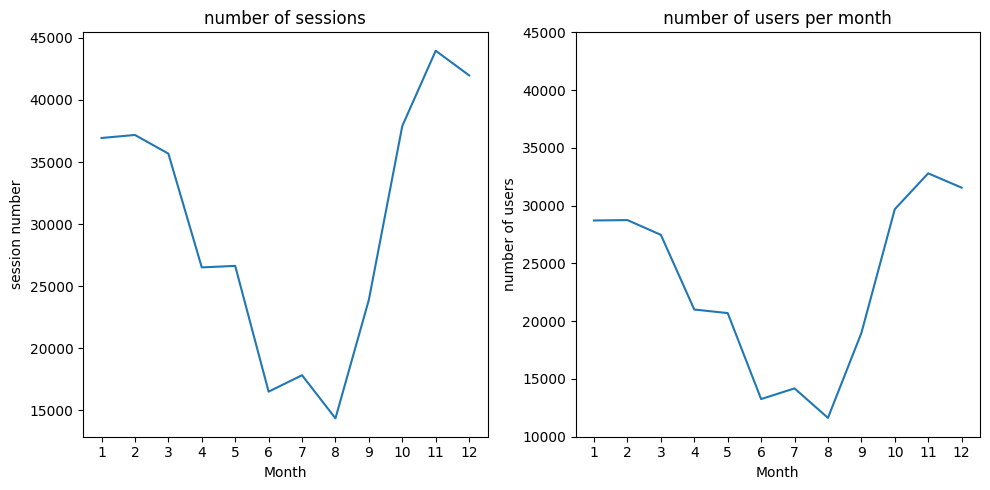

In [13]:
plt.figure(figsize=(10,5))

# session number 
plt.subplot(1,2,1)
sns.lineplot(data=sessions_per_day, x='start_m', y='session_number')
plt.title('number of sessions')
plt.ylabel('session number')
plt.xlabel('Month')
plt.xticks(np.arange(1,13,1))

# number of users per month 
plt.subplot(1,2,2)
sns.lineplot(data=sessions_per_day, x='start_m', y='number_user')
plt.title(' number of users per month ')
plt.ylabel('number of users')
plt.xlabel('Month')
plt.yticks(np.arange(10000,50000,5000))
plt.xticks(np.arange(1,13,1))


plt.tight_layout()
plt.show()

In [39]:
# Duration for each session 
# calculation hour
visits['duration_session_hour']  = (visits['start_ts'] - visits['end_ts']).dt.components.hours

duration_session = visits.groupby(['duration_session_hour','start_y', 'start_m']).agg({'uid':'count'}).reset_index()
duration_session = duration_session.rename(columns={'uid': 'number_session'})
duration_session

,duration_session_hour,start_y,start_m,number_session
0,0,2017,6,1731
1,0,2017,7,1835
2,0,2017,8,1443
3,0,2017,9,2415
4,0,2017,10,3806
...,...,...,...,...
96,23,2018,1,32600
97,23,2018,2,32924
98,23,2018,3,31543
99,23,2018,4,23358


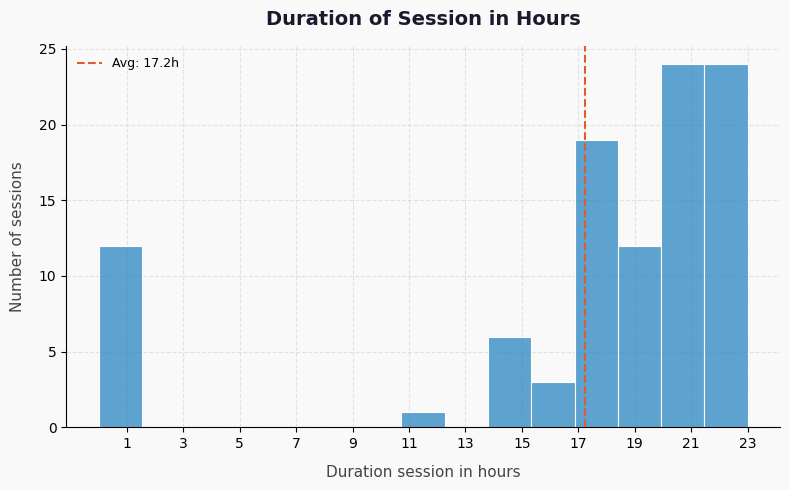

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

sns.histplot(
    data=duration_session,
    x='duration_session_hour',
    bins=15,
    color='#2a85c2',
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

# Línea de promedio
avg = duration_session['duration_session_hour'].mean()
ax.axvline(avg, color='#e05c2a', linestyle='--', linewidth=1.5, label=f'Avg: {avg:.1f}h')
ax.legend(fontsize=9, framealpha=0)

# Ejes y títulos
ax.set_title('Duration of Session in Hours', fontsize=14, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('Duration session in hours', fontsize=11, color='#444444', labelpad=10)
ax.set_ylabel('Number of sessions', fontsize=11, color='#444444', labelpad=10)
ax.set_xticks(np.arange(1, 24, 2))

# Grilla y bordes
ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
# how often the costumer come back 
first_visits = visits.groupby('uid').agg({'start_ts':'min'}).reset_index()
first_visits.columns= ['uid','first_session_start_ts']

first_visits['first_session_dt'] = first_visits['first_session_start_ts'].dt.date
first_visits['first_session_month'] = first_visits['first_session_start_ts'].dt.to_period('M').dt.start_time

# merge 
visits_co = pd.merge(first_visits, visits, on ='uid')

# calculate visits life cicle 
visits_co['life_cicle'] = (visits_co['session_month'].dt.month - visits_co['first_session_month'].dt.month )
visits_co['life_cicle'] += 12*(visits_co['session_month'].dt.year - visits_co['first_session_month'].dt.year)


In [45]:
retention = visits_co.pivot_table(
    index = 'first_session_month',
    columns = 'life_cicle',
    values = 'uid',
    aggfunc= 'nunique'
)
retention.fillna('')

life_cicle,0,1,2,3,4,5,6,7,8,9,10,11
first_session_month,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,,
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,,,
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,,,,
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,,,,,
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,,,,,,
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,,,,,,,
2018-02-01,22197.0,1267.0,565.0,446.0,,,,,,,,


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_28388\417613289.py:3: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  retention_a = pd.concat([retention_a,retention[col]/retention[0]],axis = 1)


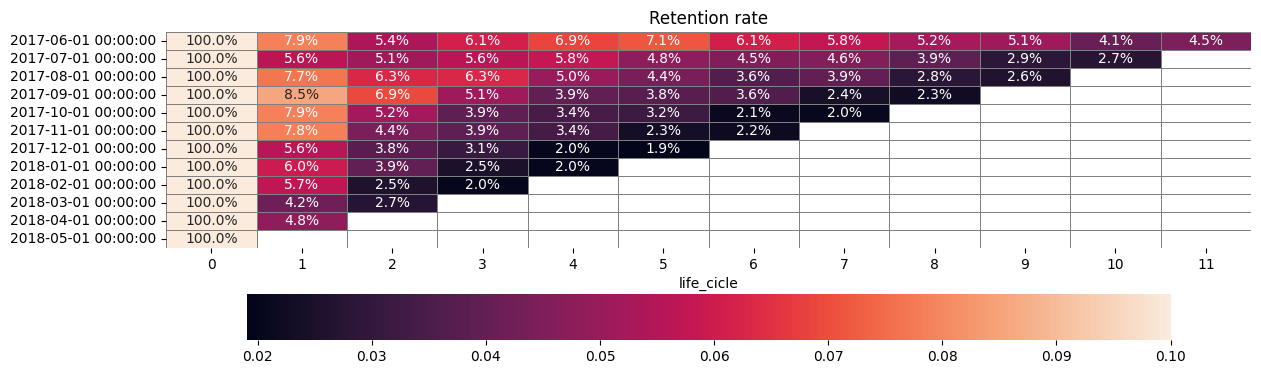

In [ ]:
retention_a = pd.DataFrame()
for col in retention.columns:
    retention_a = pd.concat([retention_a,retention[col]/retention[0]],axis = 1)

retention_a.columns = retention.columns

plt.figure(figsize=(14,4))
sns.heatmap(retention_a,
            annot=True,
            fmt='.1%',
            linewidths=0.5,
            linecolor='grey',
            vmax= 0.1,
            cbar_kws={'orientation':'horizontal'}
            )

plt.title('Retention rate')

plt.show()

## **Purchase** ##

When do people start buying, KPI time between registration and conversion

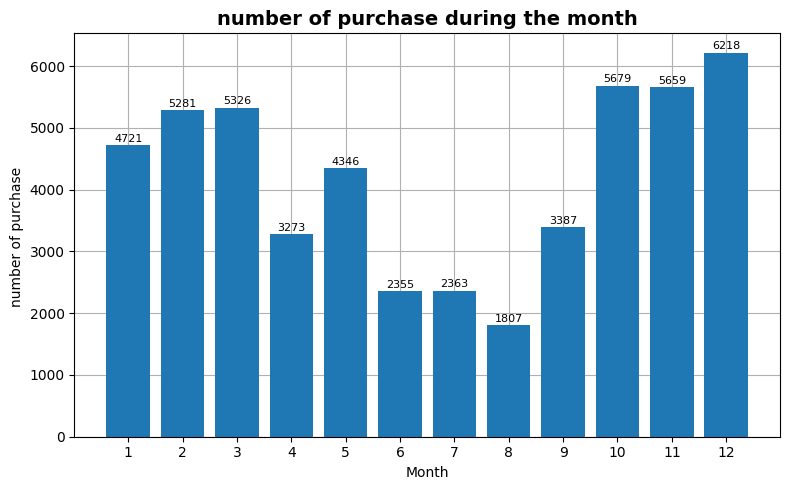

In [50]:
# number of purchase during the month 
n_order = orders.copy()
n_order['week'] = n_order['buy_ts'].dt.isocalendar().week
n_order['month'] = n_order['buy_ts'].dt.month
n_order['day'] = n_order['buy_ts'].dt.day
n_order['revenue'] = n_order['revenue']
order_month = n_order.groupby('month').agg({'uid':'count'}).reset_index()


fig, ax = plt.subplots(figsize=(8,5))
ax.set_title('number of purchase during the month',loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold','color':'black'})
ax.grid()
ax.bar(order_month['month'],order_month['uid'])
ax.set_xlabel('Month')
ax.set_ylabel('number of purchase ')
ax.set_xticks(range(1,13))
for container in ax.containers:
    ax.bar_label(container, fmt = '%.0f',label_type='edge', padding=1,color='black', fontsize=8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



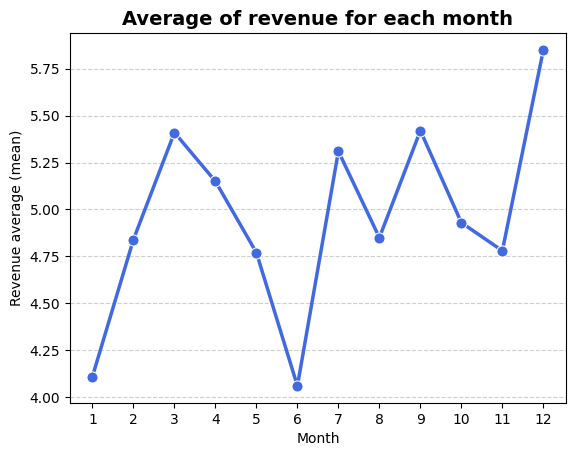

In [22]:
# average of purchases 
month_mean = n_order.groupby('month').agg({'revenue':'mean'}).round(2)
month_mean
plt.title('Average of revenue for each month', loc= "center", fontdict = {'fontsize':14, 'fontweight':'bold','color':'black'})
sns.lineplot(data = month_mean,
        x = 'month',
        y = 'revenue',
        color='royalblue',
        marker='o',
        linewidth=2.5,
        markersize=8
        )
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.6)
plt.xlabel('Month')
plt.ylabel('Revenue average (mean)')
plt.xticks( np.arange(1,13,1));

Identification behaviour between average of purchases and revenue of purchases 

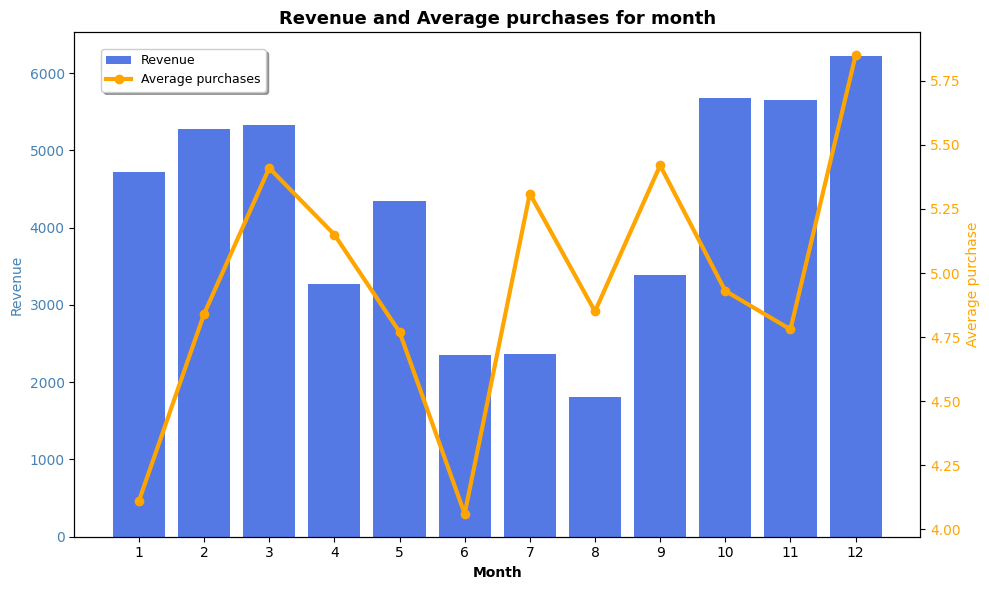

In [23]:
comparation = pd.merge(order_month, month_mean, on = 'month')

fig, ax1 = plt.subplots(figsize=(10, 6))

bars= ax1.bar(comparation['month'],
            comparation['uid'],
            label='Revenue',
            color= 'royalblue',
            alpha = 0.9
            )

ax1.set_xlabel('Month', fontsize= 10, fontweight = 'bold')
ax1.set_ylabel('Revenue', color = 'steelblue',fontsize = 10)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()

line = ax2.plot(
    comparation['month'],
    comparation['revenue'],
    label='Average purchases',
    color = 'orange',
    marker= 'o',
    linewidth = 3
    )

ax2.set_ylabel('Average purchase', color= 'orange')
ax2.tick_params(axis='y', labelcolor='orange')

fig.legend(
    loc = 'upper left',
    bbox_to_anchor = (0.1,0.92),
    frameon = True,
    shadow= True,
    fontsize = 9
    )

plt.title('Revenue and Average purchases for month', fontsize=13, fontweight='bold')
plt.xticks(np.arange(1,13,1))
# Quita la segunda leyenda repetida
plt.tight_layout()
plt.show()

## **LTV** ##
Life Time Value 

In [24]:
first_order = orders.groupby('uid').agg({'buy_ts':'min'}).reset_index()
first_order.columns= ['uid','first_order_start_ts']

first_order['first_order_dt'] = first_order['first_order_start_ts'].dt.date
first_order['first_order_month'] = first_order['first_order_start_ts'].dt.to_period('M').dt.start_time
first_order

orders['order_month'] = orders['buy_ts'].dt.to_period('M').dt.start_time
buyers = pd.merge(first_order,orders, on = 'uid')


cohort_size = buyers.groupby('first_order_month').agg({'uid':'nunique'}).reset_index()
cohort_size.rename(columns = {'uid':'n_buyer'},inplace=True)

cohort =buyers.groupby(['first_order_month','order_month']).agg({'revenue':'sum'}).reset_index()

cohort['life_cicle'] = (cohort['order_month'].dt.month - cohort['first_order_month'].dt.month )
cohort['life_cicle'] += 12*(cohort['order_month'].dt.year - cohort['first_order_month'].dt.year)
cohort

,first_order_month,order_month,revenue,life_cicle
0,2017-06-01,2017-06-01,9557.49,0
1,2017-06-01,2017-07-01,981.82,1
2,2017-06-01,2017-08-01,885.34,2
3,2017-06-01,2017-09-01,1931.30,3
4,2017-06-01,2017-10-01,2068.58,4
...,...,...,...,...
74,2018-03-01,2018-05-01,1114.87,2
75,2018-04-01,2018-04-01,10600.69,0
76,2018-04-01,2018-05-01,1209.92,1
77,2018-05-01,2018-05-01,13925.76,0


In [25]:
cohort_report = pd.merge(cohort_size, cohort, on = 'first_order_month')

cohort_report['ltv'] = cohort_report['revenue']/cohort_report['n_buyer']
cohort_report

,first_order_month,n_buyer,order_month,revenue,life_cicle,ltv
0,2017-06-01,2023,2017-06-01,9557.49,0,4.724414
1,2017-06-01,2023,2017-07-01,981.82,1,0.485329
2,2017-06-01,2023,2017-08-01,885.34,2,0.437637
3,2017-06-01,2023,2017-09-01,1931.30,3,0.954671
4,2017-06-01,2023,2017-10-01,2068.58,4,1.022531
...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,1114.87,2,0.315559
75,2018-04-01,2276,2018-04-01,10600.69,0,4.657597
76,2018-04-01,2276,2018-05-01,1209.92,1,0.531599
77,2018-05-01,2988,2018-05-01,13925.76,0,4.660562


In [26]:
ltv_table = cohort_report.pivot_table(
    index= 'first_order_month',
    columns = 'life_cicle',
    values= 'ltv',
    aggfunc= 'sum'
)
ltv_table.round(2).fillna('')

life_cicle,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.72,0.49,0.44,0.95,1.02,0.74,0.95,0.58,0.55,0.61,0.57,0.26
2017-07-01,6.01,0.34,0.62,0.36,0.18,0.16,0.12,0.14,0.16,0.15,0.16,
2017-08-01,5.28,0.47,0.46,0.39,0.49,0.28,0.21,0.41,0.29,0.19,,
2017-09-01,5.64,1.12,0.52,3.98,0.4,0.65,0.7,0.24,0.18,,,
2017-10-01,5.00,0.54,0.19,0.16,0.15,0.12,0.08,0.12,,,,
2017-11-01,5.15,0.4,0.2,0.32,0.15,0.05,0.11,,,,,
2017-12-01,4.74,0.26,0.93,1.07,0.31,0.34,,,,,,
2018-01-01,4.14,0.29,0.3,0.14,0.06,,,,,,,
2018-02-01,4.16,0.28,0.08,0.07,,,,,,,,


<Axes: title={'center': 'LIFE TIME VALUE (LTV)'}, xlabel='life_cicle', ylabel='first_order_month'>

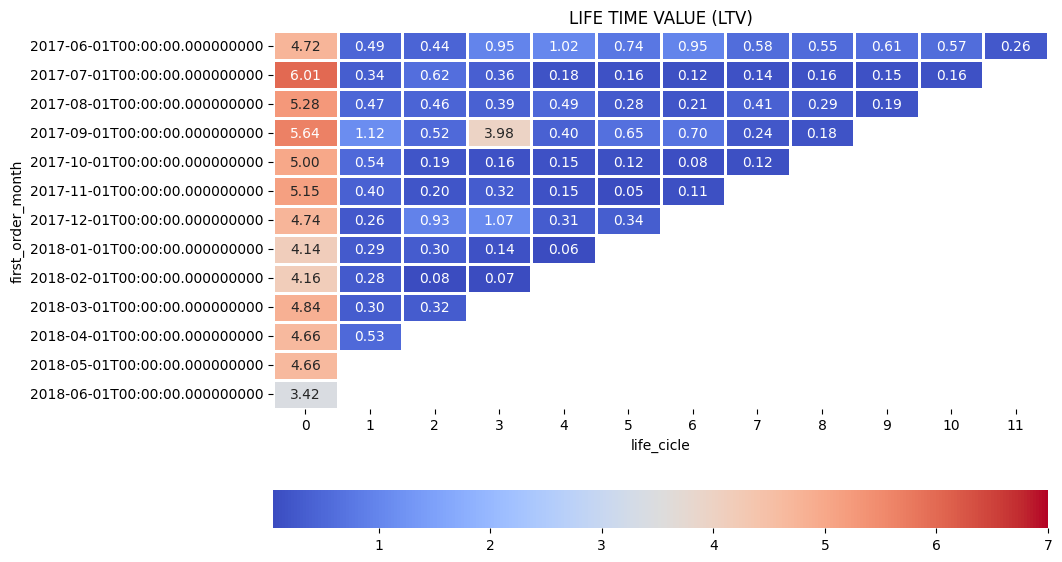

In [27]:
plt.figure(figsize = (10,7))
plt.title('LIFE TIME VALUE (LTV)')
sns.heatmap(
    ltv_table,
    annot = True,
    fmt = '.2f',
    linewidths = 1,
    linecolor = 'white',
    cmap="coolwarm",
    vmax= 7,
    cbar_kws={'orientation':'horizontal'}
)


## **Marketing** ##
1. Cost of the promotional marketing

In [28]:
# total cost 
total_cost = costs['costs'].sum()
print(f'total cost in marketing {total_cost}')

total cost in marketing 329131.62


In [29]:
#  expenses by source of acquisition 
source_cost  = costs.groupby('source_id').agg(costs_by_source = ('costs', 'sum')).reset_index
print(source_cost)

<bound method DataFrame.reset_index of            costs_by_source
source_id                 
1                 20833.27
2                 42806.04
3                141321.63
4                 61073.60
5                 51757.10
9                  5517.49
10                 5822.49>


In [30]:
#  Costs according the month  
costs['cost_month'] = costs['dt'].dt.to_period('M')
date_cost = (costs.groupby('cost_month')['costs'].sum()).round()
print(date_cost)

cost_month
2017-06    18015.0
2017-07    18241.0
2017-08    14791.0
2017-09    24369.0
2017-10    36323.0
2017-11    37908.0
2017-12    38315.0
2018-01    33519.0
2018-02    32723.0
2018-03    30415.0
2018-04    22289.0
2018-05    22224.0
Freq: M, Name: costs, dtype: float64


## **CAC** ##  
Customer Acquisition Cost

In [31]:
# CAC   Customer Acquisition
cohort_report['first_order_month'] = cohort_report['first_order_month'].dt.to_period('M')
# Unir los DataFrames
report_ = pd.merge(cohort_report, costs, left_on='first_order_month', right_on='cost_month')
report_['cac'] = report_['costs']/ report_['n_buyer']
report_
#  rentability per user 
report_['finance_order'] = report_.apply(
    lambda x: 'profitable' if x['ltv'] > x['cac'] else 'not_profitable', axis=1
)
report_




,first_order_month,n_buyer,order_month,revenue,life_cicle,ltv,source_id,dt,costs,cost_month,cac,finance_order
0,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-01,75.20,2017-06,0.037173,profitable
1,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-02,62.25,2017-06,0.030771,profitable
2,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-03,36.53,2017-06,0.018057,profitable
3,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-04,55.00,2017-06,0.027187,profitable
4,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-05,57.08,2017-06,0.028216,profitable
...,...,...,...,...,...,...,...,...,...,...,...,...
16595,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-27,9.92,2018-05,0.003320,profitable
16596,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-28,21.26,2018-05,0.007115,profitable
16597,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-29,11.32,2018-05,0.003788,profitable
16598,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-30,33.15,2018-05,0.011094,profitable


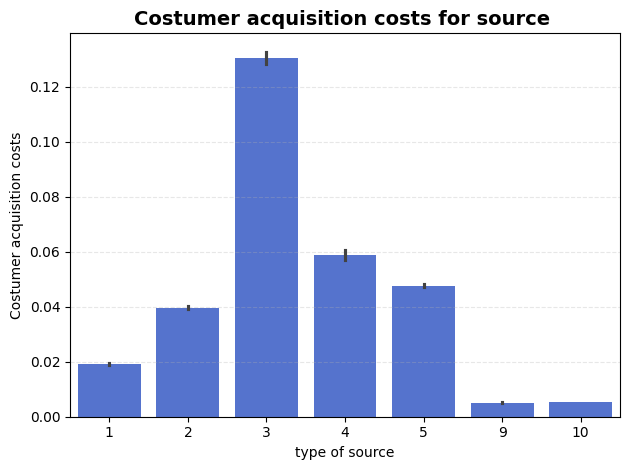

In [32]:
plt.title('Costumer acquisition costs for source ', loc= "center", fontdict = {'fontsize':14, 'fontweight':'bold','color':'black'})
sns.barplot(
    data=report_,
    x='source_id',
    y='cac',
    color='royalblue',
   
)
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)

plt.xlabel('type of source')
plt.ylabel('Costumer acquisition costs')

plt.tight_layout()
plt.show()



In [33]:
#  How much the clients pay depending on the source 
costs_report = report_.groupby(['source_id']).agg(
    revenue_source = ('revenue','mean'),
    costs_source = ('costs','sum')

).round(2).reset_index()
costs_report['revenue_source'] = (12*costs_report['revenue_source'])
costs_report

,source_id,revenue_source,costs_source
0,1,38645.52,127585.19
1,2,38645.52,263847.09
2,3,38645.52,868903.37
3,4,38645.52,378008.44
4,5,38694.12,317923.30
5,9,38645.52,34077.70
6,10,38645.52,36070.85


In [34]:

rev_max = costs_report['revenue_source'].max()
rev_sou_max = costs_report.loc[costs_report['revenue_source'].idxmax(),'source_id']

rev_min = costs_report['revenue_source'].min()
rev_sou_min = costs_report.loc[costs_report['revenue_source'].idxmin(),'source_id']

cost_max = costs_report['costs_source'].max()
cost_sou_max = costs_report.loc[costs_report['costs_source'].idxmax(),'source_id']

cost_min = costs_report['costs_source'].min()
cost_sou_min = costs_report.loc[costs_report['costs_source'].idxmin(),'source_id']

print('max revenue source {}, value ${}'.format(rev_sou_max,rev_max))
print('min revenue source {}, value ${}'.format(rev_sou_min,rev_min))
print('max costs source {}, value ${}'.format(cost_sou_max,cost_max))
print('min costs source {}, value ${}'.format(cost_sou_min,cost_min))

max revenue source 5, value $38694.12
min revenue source 1, value $38645.520000000004
max costs source 3, value $868903.37
min costs source 9, value $34077.7


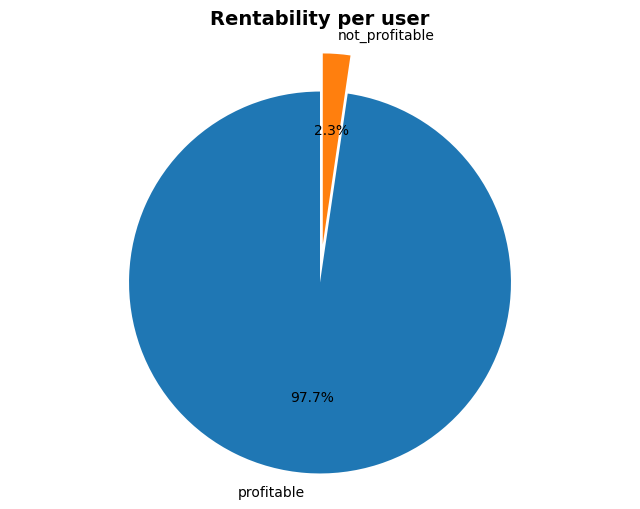

In [35]:
# graph rentability per user 
rentability_user = report_['finance_order'].value_counts().reset_index()

myexplode  = [0.1] * len(rentability_user)
plt.figure(figsize=(8,6))
plt.pie(rentability_user['count'],
        labels=rentability_user['finance_order'],
        autopct='%1.1f%%',
        startangle=90,
        explode = myexplode,
        textprops={'color': 'black', 'fontsize': 10}
    )

plt.title('Rentability per user', loc= "center", fontdict = {'fontsize':14, 'fontweight':'bold','color':'black'})
plt.axis('equal')
plt.show()

**ROMI**  (Return on marketing investment)

In [36]:
report_['romi'] = report_['ltv']/report_['cac']
report_

,first_order_month,n_buyer,order_month,revenue,life_cicle,ltv,source_id,dt,costs,cost_month,cac,finance_order,romi
0,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-01,75.20,2017-06,0.037173,profitable,127.094282
1,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-02,62.25,2017-06,0.030771,profitable,153.533976
2,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-03,36.53,2017-06,0.018057,profitable,261.633999
3,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-04,55.00,2017-06,0.027187,profitable,173.772545
4,2017-06,2023,2017-06-01,9557.49,0,4.724414,1,2017-06-05,57.08,2017-06,0.028216,profitable,167.440259
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16595,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-27,9.92,2018-05,0.003320,profitable,1403.806452
16596,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-28,21.26,2018-05,0.007115,profitable,655.021637
16597,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-29,11.32,2018-05,0.003788,profitable,1230.190813
16598,2018-05,2988,2018-05-01,13925.76,0,4.660562,10,2018-05-30,33.15,2018-05,0.011094,profitable,420.083258


In [37]:
output = report_.pivot_table(
    index='first_order_month', 
    columns='life_cicle', 
    values='romi', 
    aggfunc='mean'
)
output.fillna('').round(2)

life_cicle,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,462.05,47.465442,42.80118,93.367428,100.004139,71.932513,92.9536,56.880019,54.10457,59.246475,55.869622,25.120687
2017-07,693.23,38.663864,71.91931,41.404961,20.391483,17.998871,13.865033,16.357812,18.596874,16.97201,17.955685,
2017-08,498.69,44.608392,43.331462,36.979924,46.693148,26.797596,19.910038,38.27755,27.61715,17.765954,,
2017-09,462.29,91.530974,42.664466,325.619752,32.805932,52.995174,57.462104,19.914125,15.070217,,,
2017-10,621.55,66.5514,23.774592,19.520267,18.826478,14.951103,10.535638,14.343465,,,,
2017-11,445.64,34.515353,17.252486,28.093468,12.796316,4.658059,9.935978,,,,,
2017-12,453.38,24.914464,88.519896,101.933126,29.943333,32.346755,,,,,,
2018-01,378.54,26.979639,27.851263,13.068661,5.738825,,,,,,,
2018-02,392.34,26.263798,7.410363,6.997785,,,,,,,,


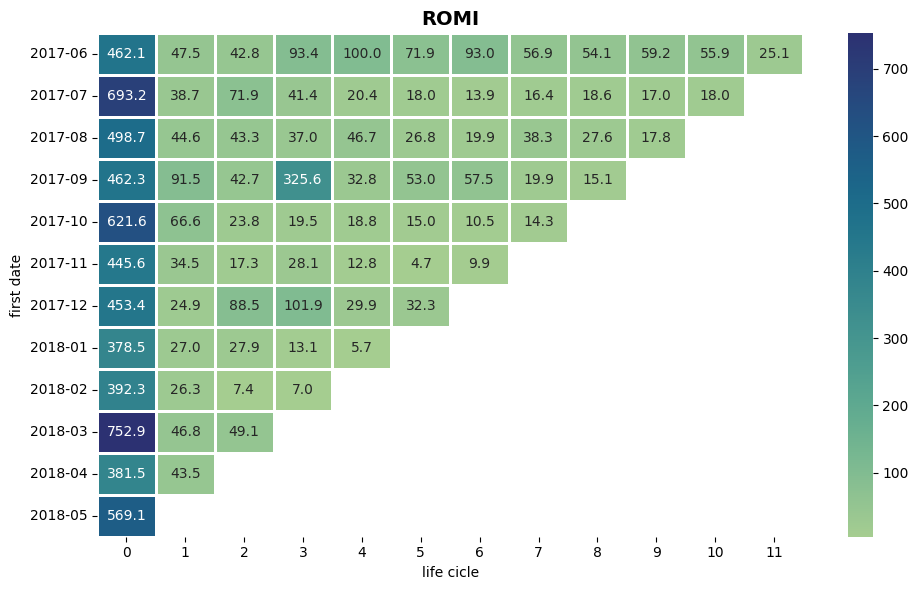

In [38]:
plt.figure(figsize = (10,6))
plt.title('ROMI', loc= "center", fontdict = {'fontsize':14, 'fontweight':'bold','color':'black'})
sns.heatmap(
    output,
    annot = True,
    fmt = '.1f',
    linewidths = 1,
    linecolor = 'white',
    cmap="crest"
)
plt.ylabel('first date')
plt.xlabel('life cicle')
plt.tight_layout()
plt.show()

## Concluciones ##
- Teniendo en cuenta la actividad de los usuarios y el factor de adherencia media los usuarios interactuar con la página, sin embargo, no es de manera constante. Se debe buscar una forma para mantener más los compradores 
- Analizando el número de sesiones y e número de usuario se determina una relación de compartimiento en la gráfica don la cantidad de usuario se relaciona con el número de sesiones. los puntos con mayor número de usuarios he intención de desarrollan en tres el primer mes del año y los tres últimos meses del año 
- El comportamiento de compra desde que le usuario entra a la página hasta que realiza la compra final en su mayoría toma de 17 a 23 horas
- La taza de retención de los clientes en los primeros meses se mantiene sin mayor perdida; sin embargo determinado de toso los compradores que recibimos al final de cada mes la taza de retención mantiene un variación del 2%, lo permite dedicar que de desarrollo una fidelización con los clientes.
- En la comparación de graficas determinamos que los ingresos están parcialmente relacionados con el promedio de compras, analizando el punto donde el menor promedio de compras en el mes 6 los ingresos son mayores, en otros meses los compras con mayores pero sus ingresos son menores.
- LTV acorde a los ingresos que podemos esperar por cliente y CAC costo de adquisición al comprar esto valores de acuerdo con los usurario nos da una rentabilidad del 97.7% 
- Romi retorno en inversión en marketing si genera una rentabilidad, los costos de inversión permiten atraer los clientes y retornar el costo de los gatos
